# Telecom X Parte 1

# **Extracción**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

datos = pd.read_json(url)

datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# **Transformación**

In [5]:
# 1. Convertimos el DataFrame a una lista de diccionarios
datos_diccionario = datos.to_dict(orient='records')

# 2. Ahora sí aplicamos el json_normalize que querías
datos = pd.json_normalize(datos_diccionario)

datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [7]:
print(datos['Churn'].unique())

['No' 'Yes' '']


Vemos que hay datos vacíos, por lo que los limpiamos.

In [8]:
vacios_churn = datos[datos['Churn'] == ''].shape[0]
vacios_churn

224

In [9]:
datos = datos[datos['Churn'] != '']

In [10]:
# A. Convertimos las variables que ya son números enteros "limpios"
datos['customer.tenure'] = datos['customer.tenure'].astype(np.int64)
datos['customer.SeniorCitizen'] = datos['customer.SeniorCitizen'].astype(np.int64)

In [11]:
# B. Convertimos el cargo mensual a decimal
datos['account.Charges.Monthly'] = datos['account.Charges.Monthly'].astype(np.float64)

In [12]:
# C. Limpiamos y convertimos el cargo total (la variable problemática)
# Usamos un lambda con .strip() para cambiar los vacíos por '0' antes de convertir a float
datos['account.Charges.Total'] = datos['account.Charges.Total'].apply(lambda x: '0' if x.strip() == '' else x.strip())
datos['account.Charges.Total'] = datos['account.Charges.Total'].astype(np.float64)

In [13]:
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Como se ve en la documentación de pd.describe, include='O' sirve para hacer una análisis descriptivo de todo incluyendo los objetos

In [14]:
datos.describe(include='O') 

,customerID,Churn,customer.gender,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,0002-ORFBO,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,5174,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


# **Carga y analisis**

In [15]:
churn_dist = datos['Churn'].value_counts().reset_index()
churn_dist.columns = ['Churn', 'Cantidad']

/var/folders/rz/7tsnxw9j261580mf3pqvjyfc0000gn/T/ipykernel_444/2556707938.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_dist, x='Churn', y='Cantidad', palette=['forestgreen', 'tomato'])


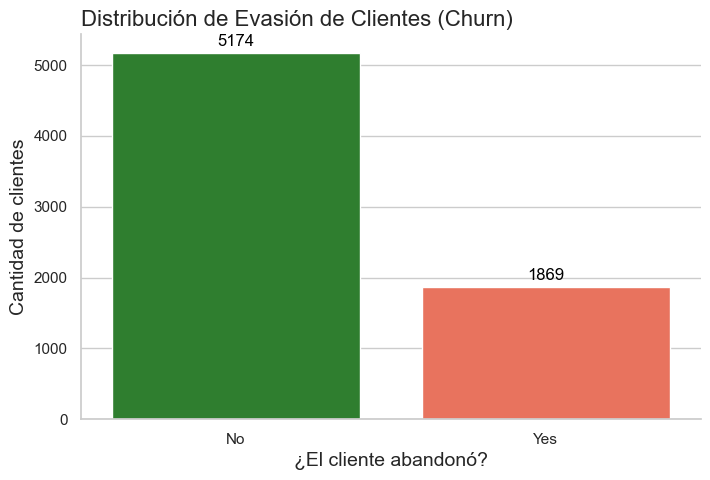

In [16]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.barplot(data=churn_dist, x='Churn', y='Cantidad', palette=['forestgreen', 'tomato'])

ax.set_title('Distribución de Evasión de Clientes (Churn)', loc='left', fontsize=16)
ax.set_xlabel('¿El cliente abandonó?', fontsize=14)
ax.set_ylabel('Cantidad de clientes', fontsize=14)

sns.despine()

for i, j in enumerate(churn_dist['Cantidad']):
    ax.text(i, j + 50, str(j), color='black', fontsize=12, ha='center', va='bottom')

plt.show()

Los clientes no abandonan tanto la empresa

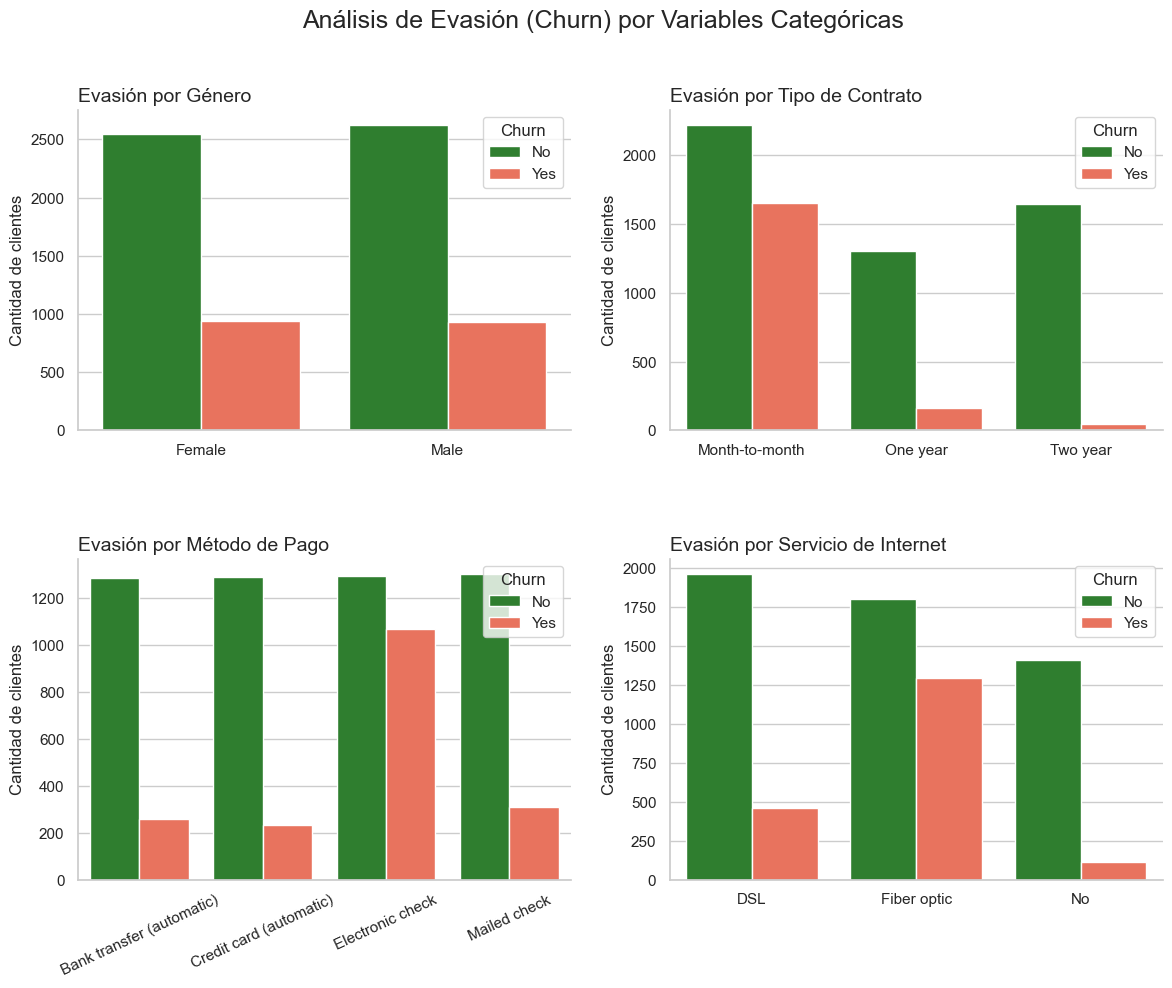

In [17]:
sns.set_theme(style='whitegrid')

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.2)
fig.suptitle('Análisis de Evasión (Churn) por Variables Categóricas', fontsize=18)

variables = ['customer.gender', 'account.Contract', 'account.PaymentMethod', 'internet.InternetService']
titulos = ['Evasión por Género', 'Evasión por Tipo de Contrato', 
           'Evasión por Método de Pago', 'Evasión por Servicio de Internet']

for i, ax in enumerate(axs.flat):
    columna = variables[i]
    
    df_agrupado = datos.groupby([columna, 'Churn']).size().reset_index(name='Cantidad')
    
    sns.barplot(data=df_agrupado, x=columna, y='Cantidad', hue='Churn', 
                palette=['forestgreen', 'tomato'], ax=ax)
    
    ax.set_title(titulos[i], loc='left', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de clientes')
    
    if columna == 'account.PaymentMethod':
        ax.xaxis.set_tick_params(rotation=25)

sns.despine()

plt.show()

/var/folders/rz/7tsnxw9j261580mf3pqvjyfc0000gn/T/ipykernel_444/3954442294.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([churn_no[col], churn_yes[col]], labels=['No', 'Yes'])
/var/folders/rz/7tsnxw9j261580mf3pqvjyfc0000gn/T/ipykernel_444/3954442294.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([churn_no[col], churn_yes[col]], labels=['No', 'Yes'])
/var/folders/rz/7tsnxw9j261580mf3pqvjyfc0000gn/T/ipykernel_444/3954442294.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([churn_no[col], churn_yes[col]], labels=['No', 'Yes'])


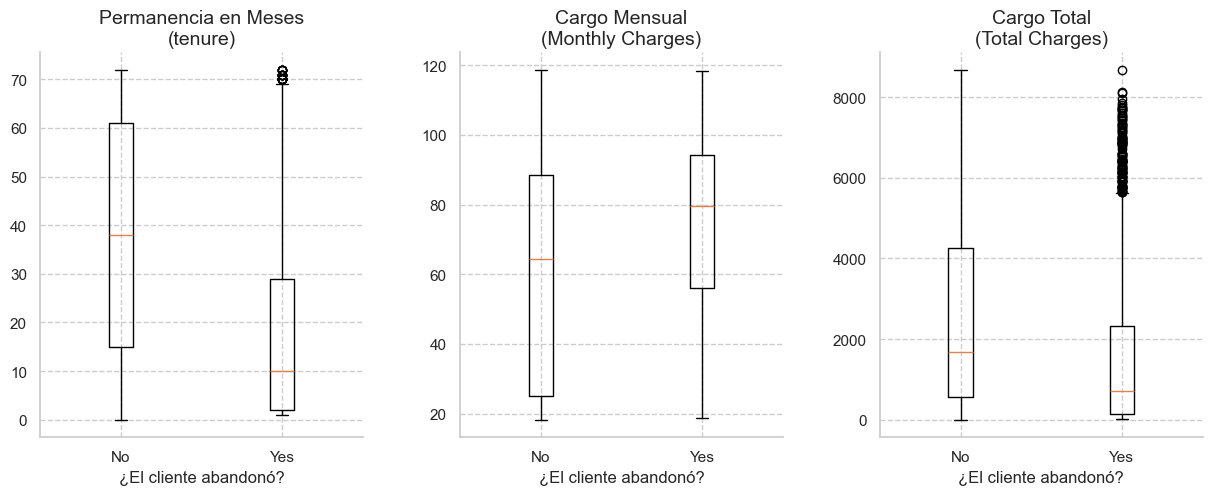

In [18]:
sns.set_theme(style='whitegrid')
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=0.3)

churn_no = datos[datos['Churn'] == 'No']
churn_yes = datos[datos['Churn'] == 'Yes']

variables = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
titulos = ['Permanencia en Meses\n(tenure)', 'Cargo Mensual\n(Monthly Charges)', 'Cargo Total\n(Total Charges)']

for i, col in enumerate(variables):
    axs[i].boxplot([churn_no[col], churn_yes[col]], labels=['No', 'Yes'])
    axs[i].set_title(titulos[i], loc='center', fontsize=14)
    axs[i].set_xlabel('¿El cliente abandonó?', fontsize=12)
    axs[i].grid(linestyle='--')

sns.despine()

plt.show()

# Informe de Análisis de Evasión de Clientes (Churn) - Telecom X

## **Introducción**

La empresa Telecom X se enfrenta a un desafío crítico: una alta tasa de cancelaciones de servicios por parte de sus usuarios. Este fenómeno, conocido como Churn (evasión de clientes), impacta directamente en los ingresos y el crecimiento de la compañía.

El objetivo principal de este análisis es comprender a fondo los factores y patrones que llevan a la pérdida de clientes. A través de un proceso integral de Extracción, Transformación y Carga (ETL) y un Análisis Exploratorio de Datos (EDA), hemos preparado y examinado la base de datos de Telecom X para extraer insights de valor. Este trabajo sienta las bases para que el equipo de Data Science desarrolle futuros modelos predictivos y permita a la gerencia diseñar estrategias de retención efectivas.

## **Limpieza y tratamiento de datos**

Para garantizar la integridad del análisis, los datos crudos extraídos de la API de Telecom X pasaron por un riguroso proceso de limpieza:

1. **Aplanamiento Estructural**: Los datos originales en formato JSON presentaban una estructura anidada (diccionarios dentro de columnas). Se utilizó la función de normalización de Pandas para expandir atributos demográficos, de cuenta y de servicios en columnas tabulares utilizables.

2. **Tratamiento de Valores Ausentes**: Se detectó que la variable objetivo (Churn) contenía valores ocultos en forma de strings vacíos (""). Estos registros fueron eliminados, ya que no aportan información viable para el análisis de evasión.

3. **Corrección de Formatos y Tipos de Datos**: * Variables numéricas clave como la permanencia en meses (tenure) y el cargo mensual (Charges.Monthly) fueron convertidas a formatos enteros y flotantes.

    - La variable de cargo total (Charges.Total) presentaba errores de formato al venir como texto y contener espacios vacíos para clientes nuevos. Se limpiaron estos espacios (reemplazándolos por 0) y se transformó la columna a tipo numérico.

4. **Estandarización de Categorías**: Se unificaron categorías redundantes en los servicios de internet y telefonía (ej. transformando "No internet service" a un simple "No") para facilitar la agrupación y visualización.

## **Análisis Exploratorio de Datos (EDA)**

Una vez limpios, los datos fueron sometidos a un análisis visual y estadístico para descubrir el comportamiento de los usuarios.

- Distribución de la Evasión: El análisis inicial reveló que el 26.5% de los clientes de la base de datos han abandonado la empresa. Esto indica una tasa de fuga preocupante y un conjunto de datos desbalanceado que el equipo de modelado predictivo deberá considerar.

- Impacto del Tipo de Contrato: Al cruzar el Churn con variables categóricas, se evidenció que la inmensa mayoría de las cancelaciones ocurren en clientes con contratos de mes a mes ("Month-to-month"), mientras que los contratos anuales o bianuales presentan tasas de evasión mínimas.

- Comportamiento Temporal (Tenure):  El análisis de cajas (boxplots) demostró que la evasión se concentra fuertemente en los primeros meses de vida del cliente (especialmente entre el mes 1 y el 15). Los clientes que superan esta barrera tienden a ser altamente leales.

- Sensibilidad al Precio: Los usuarios que cancelan el servicio tienden a tener cargos mensuales (Monthly Charges) significativamente más altos que la media de los que permanecen, sugiriendo una insatisfacción con la relación costo-beneficio en los planes más caros.

## **Conclusiones e Insights**

A partir de las visualizaciones, hemos extraído los siguientes hallazgos estratégicos:

1. **El primer año es crítico**: Telecom X no tiene un problema de retención a largo plazo, sino un problema de adopción temprana. Los clientes se van muy rápido antes de generar un cargo total significativo.

2. **El compromiso a corto plazo facilita la fuga**: El modelo de negocio basado en contratos mensuales no está logrando retener a los usuarios, dejándolos vulnerables a ofertas de la competencia.

3. **El precio como factor de fricción**: Los clientes están sintiendo el peso de las facturas más abultadas, lo que acelera su decisión de abandonar la empresa si no perciben un valor técnico o de soporte que lo justifique.

## **Recomendaciones**

Para reducir la tasa de Churn, se sugieren las siguientes acciones estratégicas:

- Incentivar la migración de contratos: Crear campañas agresivas de descuentos o beneficios adicionales para los usuarios de mes a mes que decidan actualizar su contrato a un compromiso de 1 o 2 años.

- Programa de Onboarding y Fidelización Temprana: Implementar un seguimiento proactivo de atención al cliente durante los primeros 6 a 12 meses. Asegurarse de que el usuario entienda y aproveche todos los servicios contratados para afianzar su lealtad.

- Revisión de Valor en Planes Premium: Analizar los paquetes que generan los cobros mensuales más altos. Considerar incluir sin costo extra servicios de bajo impacto operativo (como Online Security o Tech Support) en estos planes para aumentar el valor percibido y evitar la fuga por sensibilidad al precio.

# Telecom X Parte 2

In [19]:
# Eliminamos la columna 'customerID' ya que no aporta valor predictivo
datos = datos.drop(columns=['customerID'])

# Verificamos rápidamente que la columna ya no esté en nuestro dataset
print("Columnas actuales en el dataset:")
print(datos.columns.tolist())

# Mostramos las primeras filas para confirmar
datos.head()

Columnas actuales en el dataset:
['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [20]:
columnas_categoricas = datos.select_dtypes(include=['object', 'category']).columns

print("Variables a codificar:", list(columnas_categoricas))

Variables a codificar: ['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']


In [21]:
datos_codificados = pd.get_dummies(datos, columns=columnas_categoricas, drop_first=True)
datos_codificados = datos_codificados.astype(int)

print(f"\nDimensión del dataset original: {datos.shape}")
print(f"Dimensión del dataset codificado: {datos_codificados.shape}")

datos_codificados.head()


Dimensión del dataset original: (7043, 20)
Dimensión del dataset codificado: (7043, 31)


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65,593,0,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0,9,59,542,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
2,0,4,73,280,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,1,13,98,1237,1,1,1,0,1,0,...,0,1,0,1,0,0,1,0,1,0
4,1,3,83,267,1,0,1,0,1,0,...,0,1,0,0,0,0,1,0,0,1


In [23]:
# Conteo de los que cancelaron

conteo_clases = datos['Churn'].value_counts()
print("Conteo total por clase:")
print(conteo_clases)
print("-" * 30)

Conteo total por clase:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
------------------------------


In [24]:
proporcion_clases = datos['Churn'].value_counts(normalize=True) * 100
print("Proporción de cada clase (%):")
print(proporcion_clases)

Proporción de cada clase (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/var/folders/rz/7tsnxw9j261580mf3pqvjyfc0000gn/T/ipykernel_444/3392745502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x='Churn', palette='viridis')


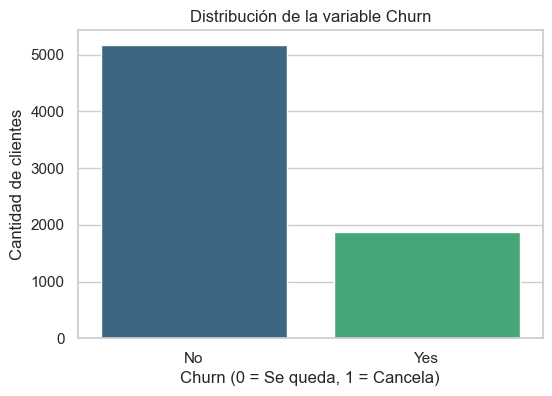

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=datos, x='Churn', palette='viridis')
plt.title('Distribución de la variable Churn')
plt.xlabel('Churn (0 = Se queda, 1 = Cancela)')
plt.ylabel('Cantidad de clientes')
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
X = datos_codificados.drop('Churn_Yes', axis=1)
y = datos_codificados['Churn_Yes']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

columnas_numericas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
scaler = StandardScaler()

X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (4930, 30)
Tamaño de X_test: (2113, 30)
